# Get Options Data

This notebook retrieves stock option chains from yfinance, allowing you to explore available expiration dates and analyze call and put option data.

## 1. Import Required Libraries

Import necessary libraries including yfinance, pandas, and visualization tools.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

## 2. Enter Stock Ticker Symbol

Specify the stock ticker symbol to retrieve options data.

In [3]:
# Enter your stock ticker here
ticker_symbol = "MSFT"
R = 0.036    # annualised risk-free rate (decimal). Use current 3-month US T-bill yield (https://ycharts.com/indicators/3_month_t_bill)

# Create a Ticker object using yfinance
ticker = yf.Ticker(ticker_symbol)

# Get current stock information
stock_info = ticker.info
current_price = stock_info.get('currentPrice', stock_info.get('regularMarketPrice', 'N/A'))

print(f"Stock: {ticker_symbol}")
print(f"Current Price: ${current_price}")
print(f"Risk-Free Rate: {R:.1%}")

Stock: MSFT
Current Price: $460.52
Risk-Free Rate: 3.6%


## 3. Retrieve Available Option Expiries

Access available expiration dates for options on the selected stock.

In [4]:
# Get all available option expiration dates
option_expirations = ticker.options
today = datetime.today()

print(f"  {'#':>3}  {'Expiry':<14}  {'DTE':>5}  {'T (yrs)':>8}  Note")
print("  " + "-" * 55)

for i, exp in enumerate(option_expirations):
    exp_dt = datetime.strptime(exp, "%Y-%m-%d")
    dte    = (exp_dt - today).days
    T_yrs  = dte / 365
    note   = ""
    if dte < 7:
        note = "very short — likely illiquid"
    elif dte > 365:
        note = "LEAPS"
    print(f"  {i:>3}  {exp:<14}  {dte:>5}  {T_yrs:>8.4f}  {note}")

print(f"\nTotal: {len(option_expirations)} expiries")

    #  Expiry            DTE   T (yrs)  Note
  -------------------------------------------------------
    0  2026-06-03          0    0.0000  very short — likely illiquid
    1  2026-06-05          2    0.0055  very short — likely illiquid
    2  2026-06-08          5    0.0137  very short — likely illiquid
    3  2026-06-10          7    0.0192  
    4  2026-06-12          9    0.0247  
    5  2026-06-18         15    0.0411  
    6  2026-06-26         23    0.0630  
    7  2026-07-02         29    0.0795  
    8  2026-07-10         37    0.1014  
    9  2026-07-17         44    0.1205  
   10  2026-08-21         79    0.2164  
   11  2026-09-18        107    0.2932  
   12  2026-10-16        135    0.3699  
   13  2026-11-20        170    0.4658  
   14  2026-12-18        198    0.5425  
   15  2027-01-15        226    0.6192  
   16  2027-03-19        289    0.7918  
   17  2027-06-17        379    1.0384  LEAPS
   18  2027-09-17        471    1.2904  LEAPS
   19  2027-12-17       

## 4. Fetch Option Chain Data

Use the option_chain() method to retrieve the complete option chain for a selected expiration date. Prefer expiries with DTE between 14 and 90 for best liquidity.

In [5]:
# Select an expiration date (you can change the index to select different expiries)
selected_expiry_index = 8   # change this to the index from the table above
selected_expiry = option_expirations[selected_expiry_index]

exp_dt          = datetime.strptime(selected_expiry, "%Y-%m-%d")
DTE             = (exp_dt - today).days
T               = DTE / 365   # time to expiry in years

opt_chain = ticker.option_chain(selected_expiry)
calls_raw = opt_chain.calls.copy()
puts_raw  = opt_chain.puts.copy()

print(f"Expiry : {selected_expiry}")
print(f"DTE    : {DTE} days")
print(f"T      : {T:.4f} years")
print(f"Calls  : {len(calls_raw)} strikes fetched")
print(f"Puts   : {len(puts_raw)} strikes fetched")

Expiry : 2026-07-10
DTE    : 37 days
T      : 0.1014 years
Calls  : 39 strikes fetched
Puts   : 30 strikes fetched


## 5. Data Quality Check

Inspect the raw chain before filtering. Common yfinance issues:
- `bid = ask = 0` → no market maker quote; option is illiquid
- `impliedVolatility = 0.00001` → yfinance floor value; IV computation failed
- `impliedVolatility = 0.500005` → yfinance ceiling/clamp artefact
- Deep ITM options have stale `lastPrice` that may be days old

In [6]:
def quality_report(df, label):
    total     = len(df)
    no_market = ((df['bid'] == 0) & (df['ask'] == 0)).sum()
    iv_floor  = (df['impliedVolatility'] <= 0.001).sum()
    iv_ceil   = (df['impliedVolatility'] >= 0.499).sum()
    has_vol   = (df['volume'].fillna(0) > 0).sum()

    print(f"{label} ({total} strikes)")
    print(f"  No bid/ask quote : {no_market:>4}  ({no_market/total:.0%})")
    print(f"  IV floor artefact: {iv_floor:>4}  ({iv_floor/total:.0%})")
    print(f"  IV ceil artefact : {iv_ceil:>4}  ({iv_ceil/total:.0%})")
    print(f"  Has volume today : {has_vol:>4}  ({has_vol/total:.0%})")
    print()

quality_report(calls_raw, f"CALLS {selected_expiry}")
quality_report(puts_raw,  f"PUTS  {selected_expiry}")

CALLS 2026-07-10 (39 strikes)
  No bid/ask quote :    0  (0%)
  IV floor artefact:    0  (0%)
  IV ceil artefact :    6  (15%)
  Has volume today :   36  (92%)

PUTS  2026-07-10 (30 strikes)
  No bid/ask quote :    0  (0%)
  IV floor artefact:    0  (0%)
  IV ceil artefact :    3  (10%)
  Has volume today :   30  (100%)



## 6. Filter for Liquidity

Keep only strikes that have a real bid/ask spread, are near the money, and have a credible IV.
The `mid` price (average of bid and ask) is used as the market price for engine comparisons — it is more reliable than `lastPrice`, which can be stale.

In [7]:
# ── FILTER PARAMS ──────────────────────────────────────────────
MONEYNESS_WIDTH = 0.25   # keep strikes within ±25% of spot
MIN_IV = 0.02       # drop yfinance IV floor artefacts
MAX_IV = 4.00       # drop extreme IV outliers
MIN_VOLUME = 0      # set to e.g. 5 to require active trading today
# ───────────────────────────────────────────────────────────────

def filter_liquid(df, spot, width, min_iv, max_iv, min_vol):
    df = df.copy()

    # Real bid/ask
    mask  = (df['bid'] > 0) & (df['ask'] > 0)
    # Near the money
    mask &= (df['strike'] >= spot * (1 - width))
    mask &= (df['strike'] <= spot * (1 + width))
    # Credible IV
    mask &= (df['impliedVolatility'] >= min_iv)
    mask &= (df['impliedVolatility'] <= max_iv)
    # Optional volume filter
    if min_vol > 0:
        mask &= (df['volume'].fillna(0) >= min_vol)

    df = df[mask].copy()
    df['mid']          = (df['bid'] + df['ask']) / 2
    df['bid_ask_spread'] = df['ask'] - df['bid']
    df['moneyness']    = df['strike'] / spot   # K/S; 1.0 = ATM
    return df.reset_index(drop=True)

calls = filter_liquid(calls_raw, current_price, MONEYNESS_WIDTH, MIN_IV, MAX_IV, MIN_VOLUME)
puts  = filter_liquid(puts_raw, current_price, MONEYNESS_WIDTH, MIN_IV, MAX_IV, MIN_VOLUME)

print(f"After filtering:")
print(f"  Calls: {len(calls)} liquid strikes  (from {len(calls_raw)})")
print(f"  Puts : {len(puts)} liquid strikes  (from {len(puts_raw)})")

if len(calls) < 5 or len(puts) < 5:
    print("\n  Very few liquid strikes. Try a later expiry (higher index).")
    print("  Or widen MONEYNESS_WIDTH to 0.35.")

After filtering:
  Calls: 38 liquid strikes  (from 39)
  Puts : 27 liquid strikes  (from 30)


## 7. Preview Filtered Data

In [8]:
display_cols = ['strike', 'moneyness', 'bid', 'ask', 'mid', 'bid_ask_spread', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney']

print(f"CALLS — {ticker_symbol} | Expiry: {selected_expiry} | Spot: ${current_price:.2f}")
print("=" * 80)
display(calls[display_cols])

print(f"\nPUTS — {ticker_symbol} | Expiry: {selected_expiry} | Spot: ${current_price:.2f}")
print("=" * 80)
display(puts[display_cols])

CALLS — MSFT | Expiry: 2026-07-10 | Spot: $460.52


,strike,moneyness,bid,ask,mid,bid_ask_spread,volume,openInterest,impliedVolatility,inTheMoney
0,350.0,0.760010,111.20,114.50,112.850,3.30,1.0,1,0.570134,True
1,355.0,0.770868,106.40,109.65,108.025,3.25,1.0,2,0.555913,True
2,370.0,0.803440,91.80,95.05,93.425,3.25,1.0,2,0.503789,True
3,380.0,0.825154,82.30,85.45,83.875,3.15,NaN,1,0.531926,True
4,385.0,0.836011,77.50,80.70,79.100,3.20,NaN,1,0.513982,True
5,390.0,0.846869,72.85,76.00,74.425,3.15,NaN,1,0.497014,True
6,395.0,0.857726,68.05,71.35,69.700,3.30,12.0,12,0.480779,True
7,400.0,0.868583,63.55,66.75,65.150,3.20,20.0,105,0.465093,True
8,405.0,0.879441,59.10,62.25,60.675,3.15,5.0,5,0.451055,True
9,410.0,0.890298,54.70,57.85,56.275,3.15,1.0,14,0.438269,True



PUTS — MSFT | Expiry: 2026-07-10 | Spot: $460.52


,strike,moneyness,bid,ask,mid,bid_ask_spread,volume,openInterest,impliedVolatility,inTheMoney
0,350.0,0.760010,0.08,0.99,0.535,0.91,1,3,0.477422,False
1,355.0,0.770868,0.18,0.73,0.455,0.55,3,23,0.432135,False
2,360.0,0.781725,0.42,0.86,0.640,0.44,3,5,0.424688,False
3,365.0,0.792582,0.52,0.99,0.755,0.47,5,9,0.415655,False
4,370.0,0.803440,0.63,1.03,0.830,0.40,11,11,0.398444,False
5,375.0,0.814297,0.76,1.27,1.015,0.51,13,9,0.394904,False
6,380.0,0.825154,0.92,1.36,1.140,0.44,383,38,0.379767,False
7,385.0,0.836011,1.11,1.59,1.350,0.48,57,40,0.371832,False
8,390.0,0.846869,1.33,1.84,1.585,0.51,77,47,0.363043,False
9,395.0,0.857726,1.63,2.21,1.920,0.58,29,75,0.357795,False


## 8. Preview Plots

Visual inspection of the raw market data. These are **not** engine analysis plots.

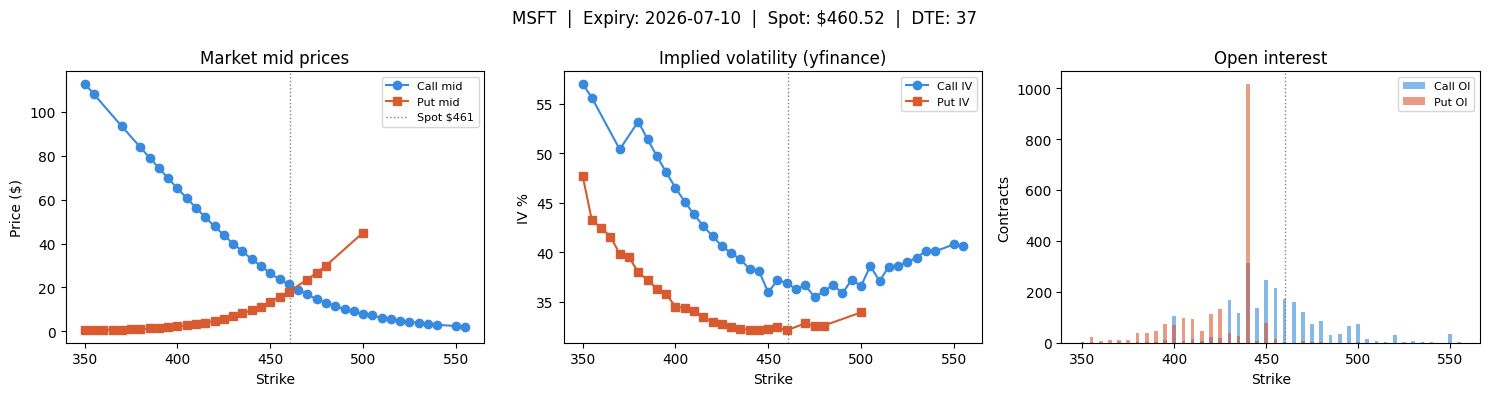

In [9]:
if len(calls) > 0 and len(puts) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{ticker_symbol}  |  Expiry: {selected_expiry}  |  Spot: ${current_price:.2f}  |  DTE: {DTE}",
                 fontsize=12)

    # --- Bid/ask mid prices ---
    ax = axes[0]
    ax.plot(calls['strike'], calls['mid'], 'o-', color='#378ADD', label='Call mid')
    ax.plot(puts['strike'],  puts['mid'],  's-', color='#D85A30', label='Put mid')
    ax.axvline(current_price, color='gray', linestyle=':', linewidth=1, label=f'Spot ${current_price:.0f}')
    ax.set_title('Market mid prices'); ax.set_xlabel('Strike')
    ax.set_ylabel('Price ($)'); ax.legend(fontsize=8)

    # --- Implied volatility smile ---
    ax = axes[1]
    ax.plot(calls['strike'], calls['impliedVolatility'] * 100, 'o-',
            color='#378ADD', label='Call IV')
    ax.plot(puts['strike'],  puts['impliedVolatility']  * 100, 's-',
            color='#D85A30', label='Put IV')
    ax.axvline(current_price, color='gray', linestyle=':', linewidth=1)
    ax.set_title('Implied volatility (yfinance)'); ax.set_xlabel('Strike')
    ax.set_ylabel('IV %'); ax.legend(fontsize=8)

    # --- Open interest ---
    ax = axes[2]
    ax.bar(calls['strike'], calls['openInterest'].fillna(0),
           width=2, alpha=0.6, color='#378ADD', label='Call OI')
    ax.bar(puts['strike'],  puts['openInterest'].fillna(0),
           width=2, alpha=0.6, color='#D85A30', label='Put OI')
    ax.axvline(current_price, color='gray', linestyle=':', linewidth=1)
    ax.set_title('Open interest'); ax.set_xlabel('Strike')
    ax.set_ylabel('Contracts'); ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough liquid strikes to plot. Adjust filter params in cell 6.")

## 9. Save Snapshot

Saves metadata + filtered call/put chains to `data/`. Paste slug into engine notebooks.

In [10]:
DATA_DIR = "data"   # relative to this notebook; change if needed
os.makedirs(DATA_DIR, exist_ok=True)

def save_snapshot(ticker_sym, expiry, spot, r, T, dte, calls_df, puts_df, out_dir="data"):
    """Save a filtered options snapshot to disk. Returns the slug string."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    slug      = f"{ticker_sym}_{expiry}_{timestamp}"

    meta = {
        "slug"      : slug,
        "ticker"    : ticker_sym,
        "expiry"    : expiry,
        "spot"      : spot,
        "r"         : r,
        "T"         : T,
        "dte"       : dte,
        "fetched_at": timestamp,
        "n_calls"   : len(calls_df),
        "n_puts"    : len(puts_df),
    }

    with open(f"{out_dir}/{slug}_meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    calls_df.to_csv(f"{out_dir}/{slug}_calls.csv", index=False)
    puts_df.to_csv( f"{out_dir}/{slug}_puts.csv",  index=False)

    return slug


if len(calls) == 0 and len(puts) == 0:
    print("No liquid data to save. Adjust filters in cell 6 first.")
else:
    slug = save_snapshot(
        ticker_sym = ticker_symbol,
        expiry     = selected_expiry,
        spot       = current_price,
        r          = R,
        T          = T,
        dte        = DTE,
        calls_df   = calls,
        puts_df    = puts,
        out_dir    = DATA_DIR,
    )
    print(f"  Snapshot saved.")
    print(f"\n  Calls : {len(calls)} strikes")
    print(f"  Puts  : {len(puts)} strikes")
    print(f"\n  Slug to use in engine notebooks:")
    print(f"\n  slug = \"{slug}\"")

  Snapshot saved.

  Calls : 38 strikes
  Puts  : 27 strikes

  Slug to use in engine notebooks:

  slug = "MSFT_2026-07-10_20260602_0230"


## 10. Batch Fetch Multiple Expiries (Instead of Single Fetching (9))

Fetch and save several expiries in one go — useful for building a vol surface or comparing near vs far dated options.

In [ ]:
# ── SELECT WHICH EXPIRY INDICES TO BATCH FETCH ─────────────────
BATCH_INDICES = [5, 8, 12, 15]   # change to whichever indices you want
# ───────────────────────────────────────────────────────────────

batch_slugs = []

for idx in BATCH_INDICES:
    if idx >= len(option_expirations):
        print(f"Index {idx} out of range — skipping.")
        continue

    exp     = option_expirations[idx]
    exp_dt  = datetime.strptime(exp, "%Y-%m-%d")
    dte_i   = (exp_dt - today).days
    T_i     = dte_i / 365

    try:
        chain   = ticker.option_chain(exp)
        c_filt  = filter_liquid(chain.calls, current_price, MONEYNESS_WIDTH, MIN_IV, MAX_IV, MIN_VOLUME)
        p_filt  = filter_liquid(chain.puts,  current_price, MONEYNESS_WIDTH, MIN_IV, MAX_IV, MIN_VOLUME)

        if len(c_filt) == 0 and len(p_filt) == 0:
            print(f"  {exp}  →  no liquid strikes after filtering, skipped.")
            continue

        s = save_snapshot(
            ticker_sym = ticker_symbol,
            expiry     = exp,
            spot       = current_price,
            r          = R,
            T          = T_i,
            dte        = dte_i,
            calls_df   = c_filt,
            puts_df    = p_filt,
            out_dir    = DATA_DIR,
        )
        batch_slugs.append(s)
        print(f"  {exp}  (DTE={dte_i:3d})  →  calls={len(c_filt)}, puts={len(p_filt)}  ✓  {s}")

    except Exception as e:
        print(f"  {exp}  →  ERROR: {e}")

print(f"\nBatch complete. {len(batch_slugs)} snapshots saved.")

## 11. List All Saved Snapshots

Run this to see what's in your `data/` folder.

In [12]:
def list_snapshots(data_dir="data"):
    if not os.path.exists(data_dir):
        print(f"No data directory found at '{data_dir}'.")
        return

    meta_files = sorted([f for f in os.listdir(data_dir) if f.endswith("_meta.json")])

    if not meta_files:
        print("No snapshots saved yet.")
        return

    print(f"{'Slug':<45}  {'Ticker':<6}  {'Expiry':<12}  {'Spot':>7}  "
          f"{'DTE':>5}  {'T':>6}  {'Calls':>6}  {'Puts':>5}  Fetched")
    print("-" * 120)

    for mf in meta_files:
        with open(os.path.join(data_dir, mf)) as f:
            m = json.load(f)
        slug = mf.replace("_meta.json", "")
        print(
            f"{slug:<45}  {m['ticker']:<6}  {m['expiry']:<12}  "
            f"${m['spot']:>6.2f}  {m.get('dte', '?'):>5}  "
            f"{m['T']:>6.4f}  {m.get('n_calls','?'):>6}  "
            f"{m.get('n_puts','?'):>5}  {m['fetched_at']}"
        )

list_snapshots(DATA_DIR)

Slug                                           Ticker  Expiry           Spot    DTE       T   Calls   Puts  Fetched
------------------------------------------------------------------------------------------------------------------------
MSFT_2026-07-10_20260602_0214                  MSFT    2026-07-10    $460.52     37  0.1014      38     27  20260602_0214
